### 1. IMPORTS

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, roc_auc_score

import joblib

### 2. LOAD DATA

In [42]:
# Load dataset
data = pd.read_csv('bank-additional-full.csv', sep=';')

print("Shape:", data.shape)
data.head()

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### 3. EDA and Cleaning

In [43]:
data.shape

(41188, 21)

In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [45]:
data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [46]:
data.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

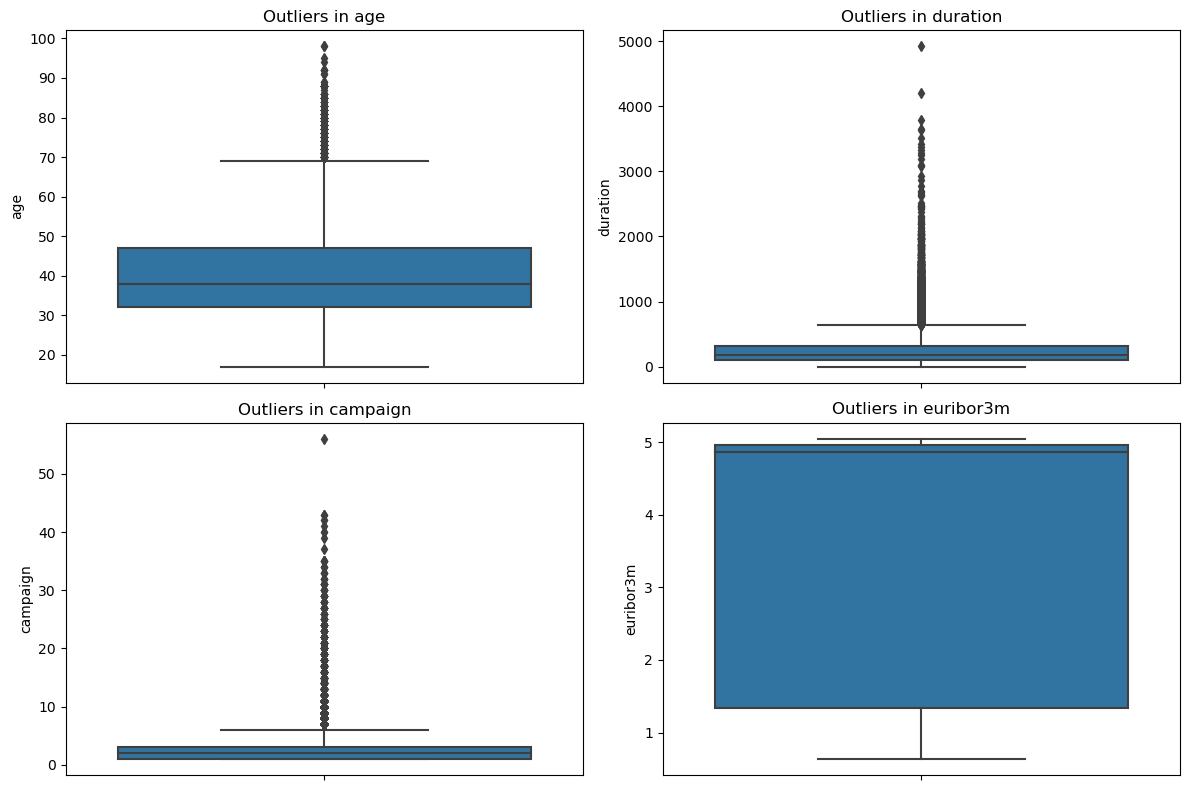

In [47]:
plt.figure(figsize=(12,8))

columns = ['age', 'duration', 'campaign', 'euribor3m']

for i, col in enumerate(columns, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=data[col])
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

Several numerical features contain outliers, particularly duration and campaign. These values are retained as they represent real-world behavior and may carry meaningful information.

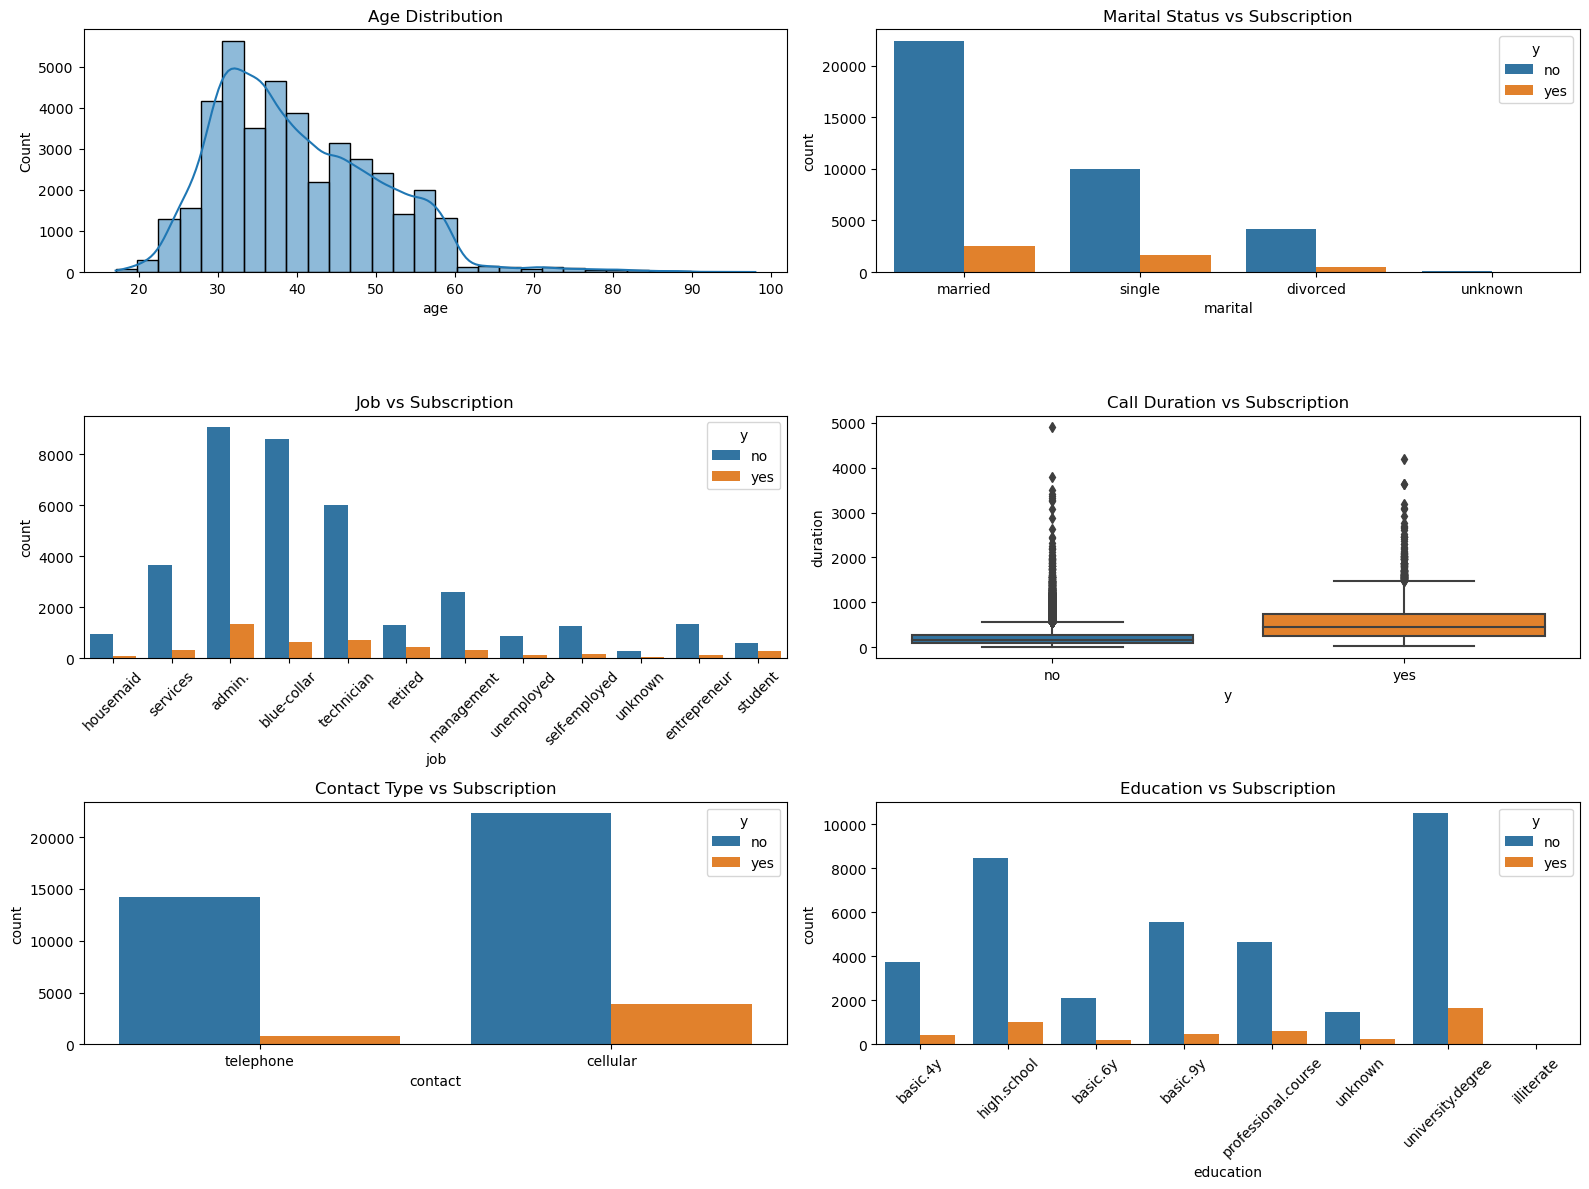

In [48]:
plt.figure(figsize=(16,12))

# 1. Age Distribution
plt.subplot(3, 2, 1)
sns.histplot(data['age'], bins=30, kde=True)
plt.title("Age Distribution")

# 2. Marital vs Target
plt.subplot(3, 2, 2)
sns.countplot(x='marital', hue='y', data=data)
plt.title("Marital Status vs Subscription")

# 3. Job vs Target
plt.subplot(3, 2, 3)
sns.countplot(x='job', hue='y', data=data)
plt.xticks(rotation=45)
plt.title("Job vs Subscription")

# 4. Duration vs Target
plt.subplot(3, 2, 4)
sns.boxplot(x='y', y='duration', data=data)
plt.title("Call Duration vs Subscription")

# 5. Contact vs Target
plt.subplot(3, 2, 5)
sns.countplot(x='contact', hue='y', data=data)
plt.title("Contact Type vs Subscription")

# 6. Education vs Target
plt.subplot(3, 2, 6)
sns.countplot(x='education', hue='y', data=data)
plt.xticks(rotation=45)
plt.title("Education vs Subscription")

plt.tight_layout()
plt.show()

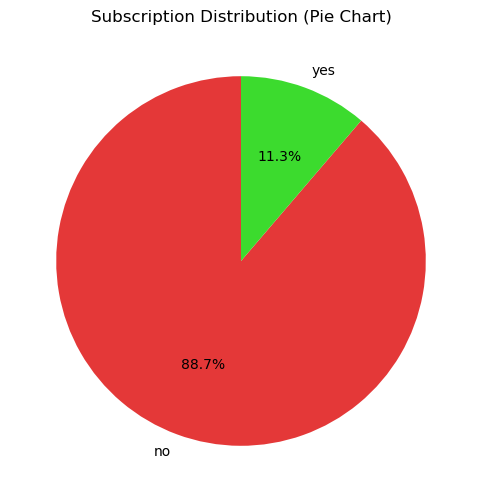

In [49]:
plt.figure(figsize=(6,6))

counts = data['y'].value_counts()

plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=["#e43838", "#3cdb2e"]
)

plt.title("Subscription Distribution (Pie Chart)")
plt.show()

Data is unbalanced

#### Target Variable Encoding

In [50]:
# Convert target to binary
y = data['y'].apply(lambda x: 1 if x == 'yes' else 0)
X = data.drop('y', axis=1)

y.value_counts()

y
0    36548
1     4640
Name: count, dtype: int64

#### Feature Separation

In [51]:
categorical_features = [
    'job', 'marital', 'education', 'default',
    'housing', 'loan', 'contact',
    'month', 'day_of_week', 'poutcome'
]

numerical_features = [
    'age', 'duration', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx',
    'cons.conf.idx', 'euribor3m', 'nr.employed'
]

#### Correlation Chart

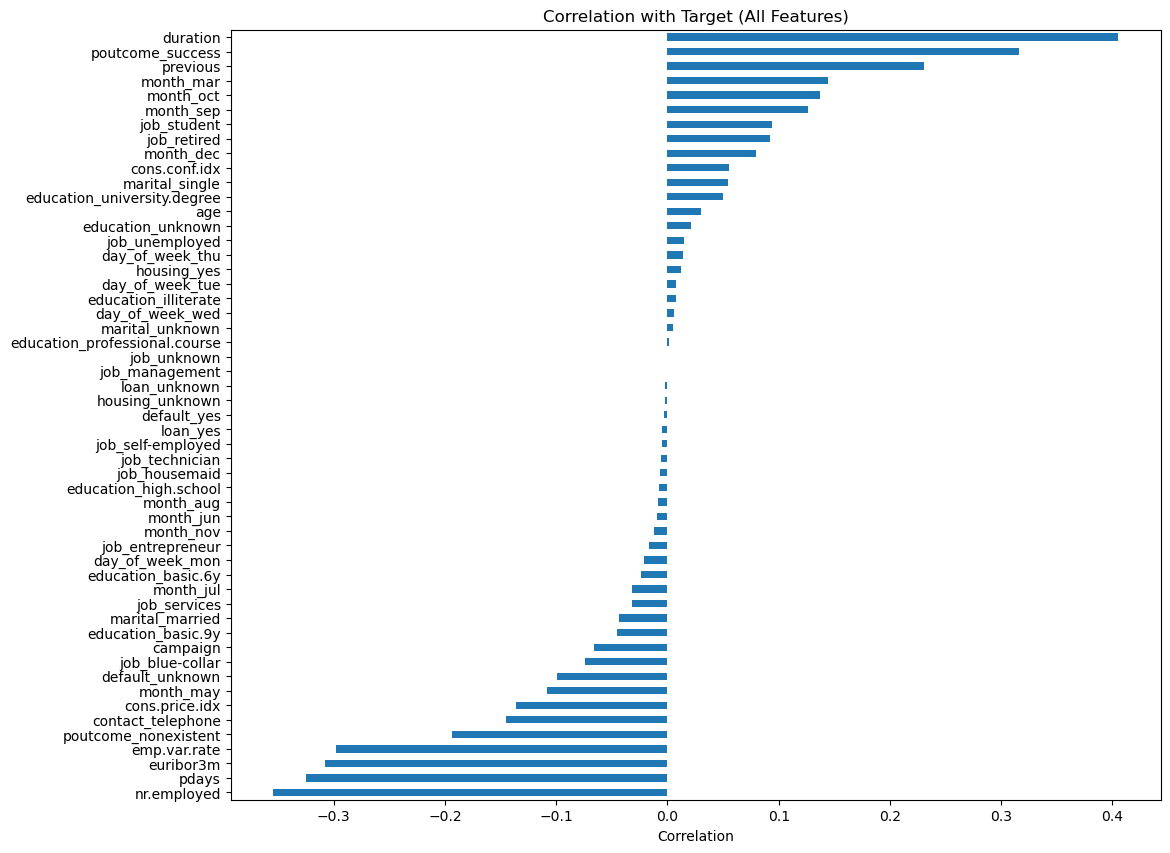

In [ ]:
# 1. Create binary target 
y_binary = data['y'].map({'yes': 1, 'no': 0})

# 2. Encode only features (exclude both y and y_binary)
encoded_data = pd.get_dummies(data.drop(columns=['y']), drop_first=True)

# 3. Add target separately with a clean name
encoded_data['target'] = y_binary

# 4. Compute correlation
correlation_values = encoded_data.corr()['target'].drop('target')

# 5. Plot
correlation_values.sort_values().plot(
    kind='barh',
    figsize=(12, 10)
)

plt.title("Correlation with Target (All Features)")
plt.xlabel("Correlation")
plt.show()

### 4. Spliting Data into Train and Test

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (32950, 20)
Test shape: (8238, 20)


### 5. Pipeline

In [54]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [55]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('svm', LinearSVC(class_weight='balanced', dual='auto', max_iter=2000))
])

### 6. HYPERPARAMETER TUNING

In [56]:
param_grid = {
    'svm__C': [0.01, 0.1, 1]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1
)

#### Model Training

In [57]:
grid.fit(X_train, y_train)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'duration',
                                                                          'campaign',
                                                                          'pdays',
                                                                          'previous',
                                                                          'emp.var.rate',
                                                                          'cons.price.idx',
                                                                          'cons.conf.idx',
                                                                          'euribor3m',
                                                                          'nr.employed']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['job',
                                                                          'marital',
                                                                          'education',
                                                                          'default',
                                                                          'housing',
                                                                          'loan',
                                                                          'contact',
                                                                          'month',
                                                                          'day_of_week',
                                                                          'poutcome'])])),
                                       ('svm',
                                        LinearSVC(class_weight='balanced',
                                                  dual='auto',
                                                  max_iter=2000))]),
             n_jobs=-1, param_grid={'svm__C': [0.01, 0.1, 1]},
             scoring='roc_auc', verbose=2)

### 7. EVALUATION

In [58]:
print("Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_

preds = best_model.predict(X_test)
decision_scores = best_model.decision_function(X_test)

print("\nClassification Report:\n", classification_report(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, decision_scores))

Best Parameters: {'svm__C': 0.01}

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.86      0.92      7310
           1       0.45      0.91      0.60       928

    accuracy                           0.86      8238
   macro avg       0.72      0.88      0.76      8238
weighted avg       0.93      0.86      0.88      8238

ROC-AUC: 0.9433089414595028


### 8. SAVE MODEL

In [59]:
joblib.dump(best_model, 'svm_model.pkl')
print("Model saved successfully ✅")

Model saved successfully ✅
